## dealias.ipynb
Author: Robby M. Frost

Organization: OU Advanced Radar Research Center

Created: 17 November 2025

Purpose: Dealias radial velocity data similar to solo3, but with mpl_point_clicker

In [1]:
# imports
import pyart
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.path import Path
from mpl_point_clicker import clicker
from matplotlib import rc
import glob
import os

# plotting set up
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['text.latex.preamble'] = r'\usepackage{bm}'
rc('font', family='sans-serif')
rc('font', weight='normal', size=6)
rc('figure', facecolor='white')
rc('axes', titlesize=8)

# make notebook interactive
%matplotlib ipympl


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



Plotting and masking functions

In [2]:
# PPI plotting function
def plot_ppi(radar, velstring, tstring, xlims, ylims):
    """
    Plot RaXPol PPI

    :param dict radar: pyart radar object
    :param str tstring: time string for plotting
    """
    display = pyart.graph.RadarDisplay(radar.extract_sweeps([0]))

    fig, axs = plt.subplots(figsize=(6,3.5), 
                            ncols=2,
                            constrained_layout=True,
                            dpi=150,
                            sharey=True)

    fig.suptitle(f"{radar.metadata['instrument_name']} {tstring} UTC (El={radar.fixed_angle['data'][0]:.1f}$^{{\\circ}}$)", 
                fontsize=10, 
                fontweight='bold')

    # reflectivity
    ax = axs[0]
    vmin, vmax = -10, 70
    display.plot_ppi('DBZ_ADJ', ax=ax, 
                    vmin=vmin, vmax=vmax,
                    cmap="Carbone42",
                    colorbar_flag=False,
                    title_use_sweep_time=False,
                    axislabels_flag=False)
    ax.set_title("Equivalent Reflectivity Factor")
    cbar0 = fig.colorbar(display.plots[0], ax=ax, orientation='horizontal', pad=0.015)
    cbar0.set_label("$Z$ [dBZ]")
    cbar0.set_ticks(np.arange(vmin, vmax + 0.001, 10))
    ax.set_ylabel("Meridional Distance [km]")
    # radial velocity
    ax = axs[1]
    vmin, vmax = -50, 50
    display.plot_ppi(velstring, ax=ax, 
                    vmin=vmin, vmax=vmax,
                    cmap="Carbone42",
                    colorbar_flag=False,
                    title_use_sweep_time=False,
                    axislabels_flag=False)
    ax.set_title("Radial Velocity")
    cbar2 = fig.colorbar(display.plots[1], ax=ax, orientation='horizontal', pad=0.015)
    cbar2.set_label("$V_r$ [m s$^{-1}$]")
    cbar2.set_ticks(np.arange(vmin, vmax + 0.001, 10))

    # clean up plot
    for iax in axs.flatten():
        iax.set_aspect('equal')
        iax.set_xlim(xlims)
        iax.xaxis.set_major_locator(MultipleLocator(1))
        iax.xaxis.set_minor_locator(MultipleLocator(0.25))
        iax.set_xlabel("Zonal Distance [km]")
        iax.set_ylim(ylims)
        iax.yaxis.set_major_locator(MultipleLocator(1))
        iax.yaxis.set_minor_locator(MultipleLocator(0.25))
        iax.grid(alpha=0.6)

    return fig, axs


# masking function
def mask_inside(xx, yy, px, py):
    """
    Mask points inside of a polygon. Useful for extracting
    data from a specific region of a storm at different 
    grid resolutions

    :param array gx: Array of x positions from dataset [km]
    :param array gy: Array of y positions from dataset [km]
    :param array px: Array of x positions of polygon [km]
    :param array py: Array of y positions of polygon [km]
    """
    # array holding polygon points
    poly_coords = np.array([list(p) for p in zip(px, py)])
    # connect polygon points
    poly_path = Path(poly_coords)

    # list of all dataset positions
    ds_pts = np.vstack((xx.ravel(), yy.ravel())).T

    # mask dataset points inside of polygon
    inside_mask = poly_path.contains_points(ds_pts)
    inside_mask = inside_mask.reshape(xx.shape)

    return inside_mask


# dealias inside mask
def dealias_in_mask(radar, 
                    n_folds, 
                    inside_mask,
                    vel_orig_field, 
                    vel_dealias_field):
    
    # important radar info
    prt = float(radar.instrument_parameters['prt']['data'][-1])
    nyquist = 0.0308077 / (prt * 4)
    
    # points that are not folded
    vel = radar.fields[vel_orig_field]['data']
    if n_folds < 0:
        unf_mask = vel < 0
    if n_folds > 0:
        unf_mask = vel > 0
    # full mask for dealiasing
    full_mask = inside_mask & unf_mask
    # mask velocity field
    vel_masked = vel[full_mask]

    # unfold masked region
    veldel = vel_masked - 2*n_folds*nyquist
    # add back to velocity field
    velnew = vel.copy()
    velnew[full_mask] = veldel

    # add back to radar object
    radar.add_field_like(vel_orig_field, vel_dealias_field, velnew, replace_existing=True)

    return radar

Read radar data

In [5]:
# directory to radar moment data
drad = "/data/arrcwx/wrt_jtrf/morton/grf/bf2/"

# desired file index
jt = 6
# desired b_factor (only needed for GRF stuff)
b_factor = 2.0

# list of full file paths
ffiles = glob.glob(f"{drad}RAXPOL*{b_factor}BF.nc")
# number of files
nfiles = len(ffiles)
# just file names
files = [os.path.basename(ffiles[jt]) for jt in range(nfiles)]


# read radar file
radar = pyart.io.read(ffiles[jt])
# adjust reflectivity
ref_adj = radar.fields['DBZ']['data'] + 20
radar.add_field_like('DBZ', 'DBZ_ADJ', ref_adj, replace_existing=True)
# fix metadata
radar.metadata['instrument_name'] = 'RaXPol'
# store params
el = float(radar.fixed_angle['data'])
prt = float(radar.instrument_parameters['prt']['data'][-1])
nyquist = 0.0308077 / (prt * 4)
# time information
tu = radar.time['units']
tplot = tu[14:-10] + " " + tu[-9:-1]

Mark region to dealias

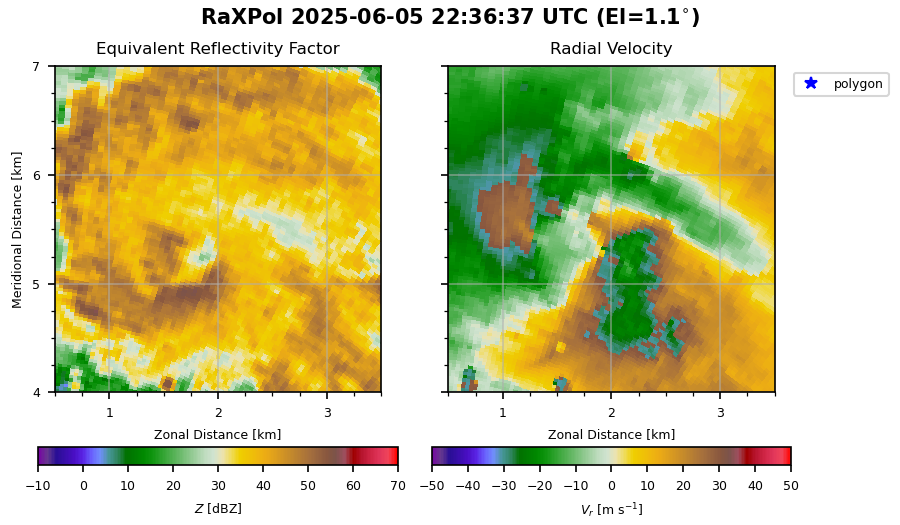

In [6]:
# make fig
fig, axs = plot_ppi(radar, 'VEL', tplot, [0.5,3.5], [4,7])
# draw points
klicker = clicker(axs[1], ["polygon"], markers=["*"], colors='black')
plt.show()

In [ ]:
# extract points from polygon
plt.close(fig)
poly_coords = klicker.get_positions()['polygon']

# close polygon
if not np.array_equal(poly_coords[0], poly_coords[-1]):
    poly_coords = np.vstack([poly_coords, poly_coords[0]])

# mask inside polygon
x, y, _ = radar.get_gate_x_y_z(0)
inside_mask = mask_inside(x/1e3, # radar x positions
                          y/1e3, # radar y positions
                          poly_coords[:,0], # polygon x positions
                          poly_coords[:,1] # polygon y positions
                          )

Dealias

In [ ]:
n_folds = 1

radar = dealias_in_mask(radar, 
                        n_folds,
                        inside_mask,
                        'VEL',
                        'VEL_DEALIAS')

In [ ]:
# make fig
fig, axs = plot_ppi(radar, 'VEL_DEALIAS', tplot, [0.5,3.5], [4,7])

plt.show()

In [ ]:
ref = radar.fields['DBZ_ADJ']['data']
vel = radar.fields['VEL']['data']
veldel = radar.fields['VEL_DEALIAS']['data']
tx, ty = 1.8, 5.0

fig, axs = plt.subplots(
    ncols=3,
    figsize=(9,4),
    sharey=True,
    constrained_layout=True,
    dpi=150
)
fig.suptitle(f"RaXPol {tplot} UTC",
             fontsize=12.5,
             fontweight='bold')

ax = axs[0]
pcm = ax.pcolormesh(x/1e3, y/1e3, 
                    ref,
                    vmin=-20, 
                    vmax=70,
                    cmap='Carbone42')
ax.set_title("Reflectivity Factor")
ax.set_ylabel("Meridional Distance [km]")
cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.015)
cbar.set_label("$Z$ [dBZ]")
cbar.set_ticks(np.arange(-20, 70 + 0.001, 10))

ax = axs[1]
pcm = ax.pcolormesh(x/1e3, y/1e3, 
                    vel,
                    vmin=-50, 
                    vmax=50,
                    cmap='Carbone42')
ax.set_title("Radial Velocity")
cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.015)
cbar.set_label("$V_r$ [m s$^{-1}$]")
cbar.set_ticks(np.arange(-50, 50+0.001, 10))

ax = axs[2]
pcm = ax.pcolormesh(x/1e3, y/1e3, 
                    veldel,
                    vmin=-50, 
                    vmax=50,
                    cmap='Carbone42')
ax.set_title("Corrected Radial Velocity")
cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.015)
cbar.set_label("$V_r$ [m s$^{-1}$]")
cbar.set_ticks(np.arange(-50, 50+0.001, 10))

for ax in axs:
    ax.set_xlim(tx-3, tx+3)
    ax.set_ylim(ty-3, ty+3)
    ax.set_aspect('equal')
    ax.set_xlabel("Zonal Distance [km]")